In [2]:
!unzip sampled_images-20260313T103937Z-3-001.zip


Streaming output truncated to the last 5000 lines.
  inflating: sampled_images/MH_VUN_2023-03-05-08.30-2-141.jpg  
  inflating: __MACOSX/sampled_images/._MH_VUN_2023-03-05-08.30-2-141.jpg  
  inflating: sampled_images/MH_UH_2023-02-11-03.30-2-35.jpg  
  inflating: __MACOSX/sampled_images/._MH_UH_2023-02-11-03.30-2-35.jpg  
  inflating: sampled_images/TN_Good_2023-02-23-08.30-2-101.jpg  
  inflating: __MACOSX/sampled_images/._TN_Good_2023-02-23-08.30-2-101.jpg  
  inflating: sampled_images/BIR_MOD_2023-02-13-09.30-2-23.jpg  
  inflating: __MACOSX/sampled_images/._BIR_MOD_2023-02-13-09.30-2-23.jpg  
  inflating: sampled_images/MH_UH_2023-02-18-11.00-1-9.jpg  
  inflating: __MACOSX/sampled_images/._MH_UH_2023-02-18-11.00-1-9.jpg  
  inflating: sampled_images/BENGR_Mod_2023-03-04-08.30-1-91.jpg  
  inflating: __MACOSX/sampled_images/._BENGR_Mod_2023-03-04-08.30-1-91.jpg  
  inflating: sampled_images/BIR_UNFSG_VF_2023-02-03-15.00-3-18.jpg  
  inflating: __MACOSX/sampled_images/._BIR_UNFSG_V

Using device: cuda
                                            Filename AQI_Class
0  sampled_images/BENGR_Good_2023-03-25-08.30-1-4...      Good
1  sampled_images/BENGR_Good_2023-02-28-08.30-1-1...      Good
2  sampled_images/BENGR_Good_2023-02-28-08.30-1-5...      Good
3  sampled_images/TN_Good_2023-02-27-16.30-1-196.jpg      Good
4  sampled_images/BENGR_Good_2023-02-27-08.30-1-2...      Good
Classes: ['Good' 'Hazardous' 'Moderate' 'Unhealthy'
 'Unhealthy for Sensitive Groups' 'Very Unhealthy']
Number of classes: 6
Train: 4200
Validation: 900
Test: 900
Epoch 1/15 TrainLoss:1.3759 ValLoss:1.1297 TrainAcc:0.4579 ValAcc:0.5744
Epoch 2/15 TrainLoss:0.9477 ValLoss:0.9083 TrainAcc:0.6317 ValAcc:0.6456
Epoch 3/15 TrainLoss:0.7200 ValLoss:0.7131 TrainAcc:0.7393 ValAcc:0.7378
Epoch 4/15 TrainLoss:0.5739 ValLoss:0.6375 TrainAcc:0.7867 ValAcc:0.7700
Epoch 5/15 TrainLoss:0.4857 ValLoss:0.5600 TrainAcc:0.8219 ValAcc:0.8111
Epoch 6/15 TrainLoss:0.3799 ValLoss:0.5535 TrainAcc:0.8681 ValAcc:0.8067
Ep

100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


Epoch 1/15 TrainLoss:1.7734 ValLoss:1.6828 TrainAcc:0.2543 ValAcc:0.3100
Epoch 2/15 TrainLoss:1.5770 ValLoss:1.5327 TrainAcc:0.3929 ValAcc:0.4033
Epoch 3/15 TrainLoss:1.4468 ValLoss:1.4282 TrainAcc:0.4612 ValAcc:0.4578
Epoch 4/15 TrainLoss:1.3575 ValLoss:1.3500 TrainAcc:0.5024 ValAcc:0.4833
Epoch 5/15 TrainLoss:1.2915 ValLoss:1.2866 TrainAcc:0.5324 ValAcc:0.5100
Epoch 6/15 TrainLoss:1.2313 ValLoss:1.2400 TrainAcc:0.5631 ValAcc:0.5367
Epoch 7/15 TrainLoss:1.1842 ValLoss:1.2008 TrainAcc:0.5831 ValAcc:0.5411
Epoch 8/15 TrainLoss:1.1533 ValLoss:1.1588 TrainAcc:0.5943 ValAcc:0.5656
Epoch 9/15 TrainLoss:1.1123 ValLoss:1.1256 TrainAcc:0.5990 ValAcc:0.5900
Epoch 10/15 TrainLoss:1.0821 ValLoss:1.0965 TrainAcc:0.6160 ValAcc:0.5878
Epoch 11/15 TrainLoss:1.0515 ValLoss:1.0775 TrainAcc:0.6310 ValAcc:0.5967
Epoch 12/15 TrainLoss:1.0351 ValLoss:1.0509 TrainAcc:0.6307 ValAcc:0.6122
Epoch 13/15 TrainLoss:1.0115 ValLoss:1.0293 TrainAcc:0.6419 ValAcc:0.6167
Epoch 14/15 TrainLoss:0.9850 ValLoss:1.0036 Tra

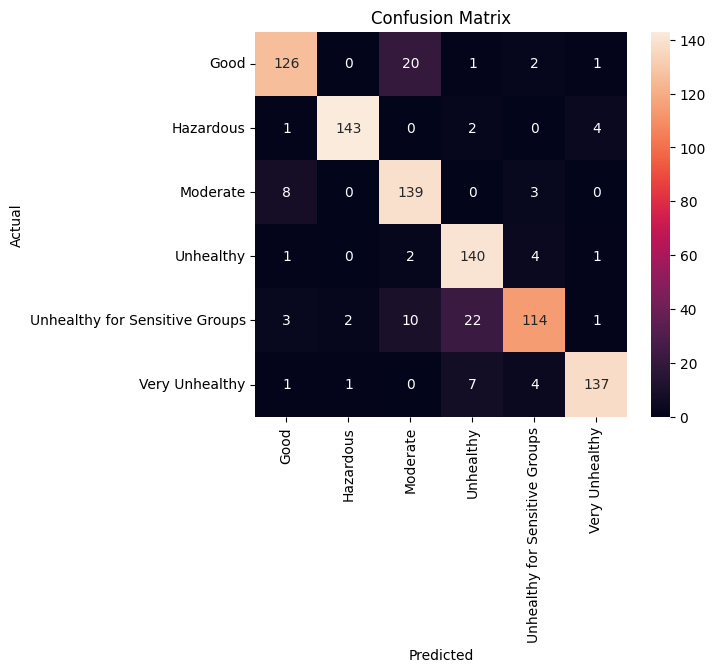

RESNET MODEL RESULTS
                                precision    recall  f1-score   support

                          Good       0.59      0.63      0.61       150
                     Hazardous       0.72      0.82      0.76       150
                      Moderate       0.65      0.59      0.62       150
                     Unhealthy       0.68      0.76      0.72       148
Unhealthy for Sensitive Groups       0.61      0.49      0.54       152
                Very Unhealthy       0.76      0.74      0.75       150

                      accuracy                           0.67       900
                     macro avg       0.67      0.67      0.67       900
                  weighted avg       0.67      0.67      0.67       900



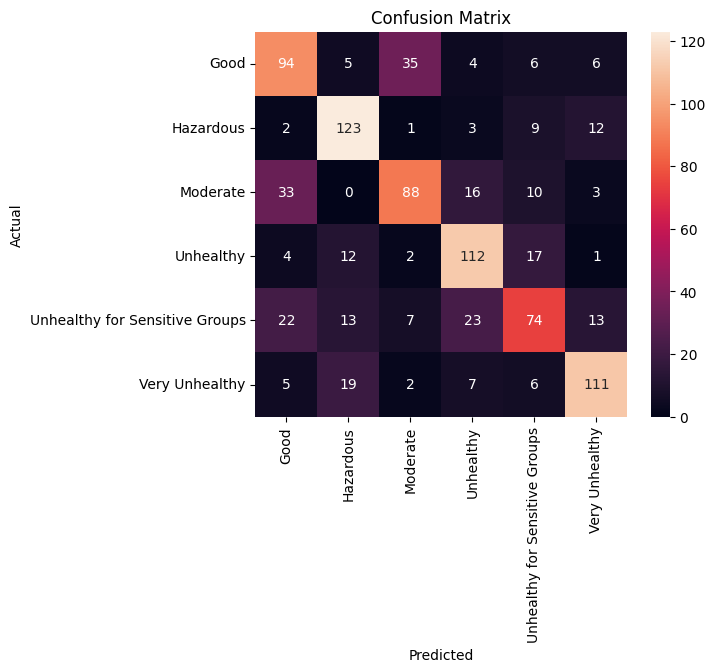

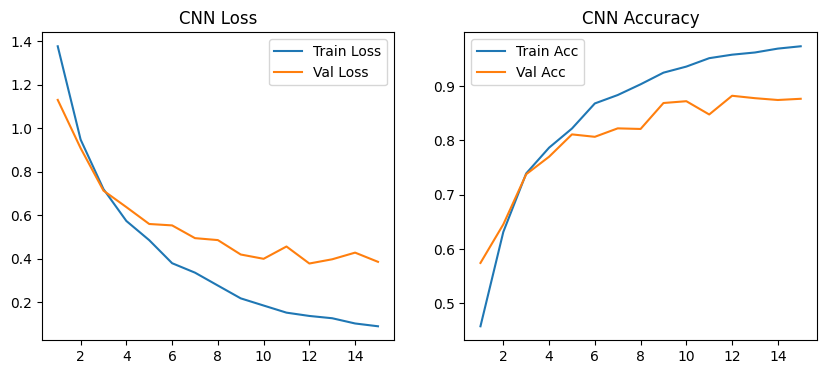

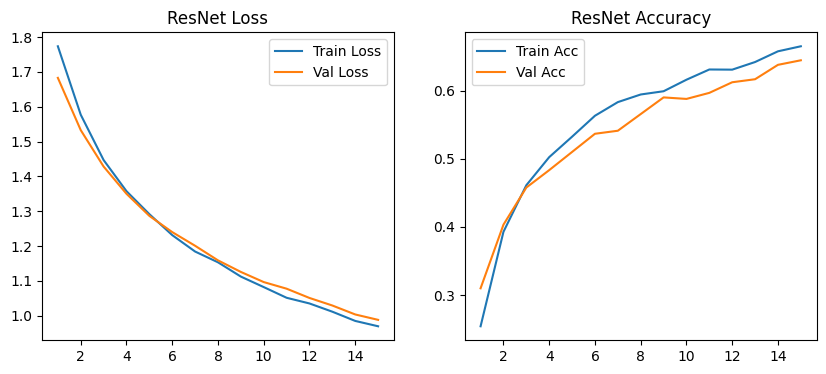

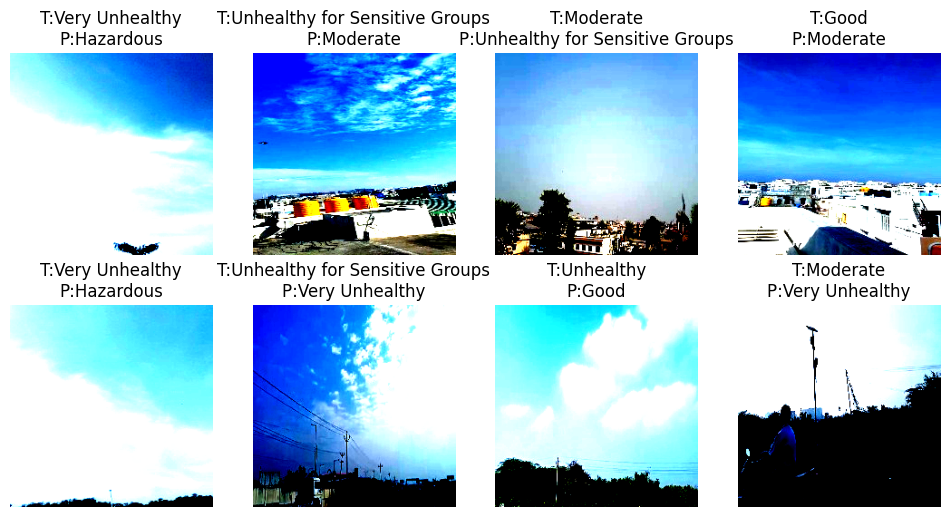

In [3]:
# =========================================================
# AQI Image Classification using CNN and Transfer Learning
# =========================================================

# Install libraries
!pip install torch torchvision scikit-learn seaborn

# =========================================================
# Import Libraries
# =========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# =========================================================
# Device Setup (Optimized for T4 GPU)
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

# =========================================================
# Load Dataset
# =========================================================

df = pd.read_csv("data.csv")

def get_aqi_class(aqi):
    if 0 <= aqi <= 50:
        return 'Good'
    elif 51 <= aqi <= 100:
        return 'Moderate'
    elif 101 <= aqi <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif 151 <= aqi <= 200:
        return 'Unhealthy'
    elif 201 <= aqi <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['AQI_Class'] = df['AQI'].apply(get_aqi_class)

# Attach image folder path
df['Filename'] = 'sampled_images/' + df['Filename']

df = df[['Filename','AQI_Class']]

print(df.head())

# =========================================================
# Encode Labels
# =========================================================

le = LabelEncoder()
df['label'] = le.fit_transform(df['AQI_Class'])

num_classes = df['label'].nunique()

print("Classes:", le.classes_)
print("Number of classes:", num_classes)

# =========================================================
# Train / Validation / Test Split
# =========================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# =========================================================
# Image Transformations
# =========================================================

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std/=[0.229,0.224,0.225]
    )
])

# =========================================================
# Dataset Class
# =========================================================

class AQIDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.iloc[idx]['Filename']
        label = self.df.iloc[idx]['label']

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================================================
# Create Datasets
# =========================================================

train_dataset = AQIDataset(train_df, transform)
val_dataset = AQIDataset(val_df, transform)
test_dataset = AQIDataset(test_df, transform)

# =========================================================
# DataLoaders (GPU Optimized)
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

# =========================================================
# Basic CNN Model
# =========================================================

class BasicCNN(nn.Module):

    def __init__(self, num_classes):

        super(BasicCNN,self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128*28*28,256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256,num_classes)
        )

    def forward(self,x):

        x = self.conv(x)
        x = self.fc(x)

        return x

# =========================================================
# Training Function
# =========================================================

def train_model(model, train_loader, val_loader, epochs=15):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    train_losses, val_losses = [], []
    train_acc, val_acc = [], []

    for epoch in range(epochs):

        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images,labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs,labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _,pred = torch.max(outputs,1)

            correct += (pred==labels).sum().item()
            total += labels.size(0)

        train_losses.append(running_loss/len(train_loader))
        train_acc.append(correct/total)

        # Validation
        model.eval()

        vloss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images,labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs,labels)

                vloss += loss.item()

                _,pred = torch.max(outputs,1)

                correct += (pred==labels).sum().item()
                total += labels.size(0)

        val_losses.append(vloss/len(val_loader))
        val_acc.append(correct/total)

        print(f"Epoch {epoch+1}/{epochs} "
              f"TrainLoss:{train_losses[-1]:.4f} "
              f"ValLoss:{val_losses[-1]:.4f} "
              f"TrainAcc:{train_acc[-1]:.4f} "
              f"ValAcc:{val_acc[-1]:.4f}")

    return train_losses, val_losses, train_acc, val_acc

# =========================================================
# Train Basic CNN
# =========================================================

cnn_model = BasicCNN(num_classes).to(device)

cnn_history = train_model(cnn_model, train_loader, val_loader, epochs=15)

# =========================================================
# Pretrained ResNet Model
# =========================================================

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in resnet.parameters():
    param.requires_grad = False

resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

resnet = resnet.to(device)

resnet_history = train_model(resnet, train_loader, val_loader, epochs=15)

# =========================================================
# Evaluation Function
# =========================================================

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images,labels in loader:

            images = images.to(device)

            outputs = model(images)

            _,pred = torch.max(outputs,1)

            y_true.extend(labels.numpy())
            y_pred.extend(pred.cpu().numpy())

    print(classification_report(y_true, y_pred,
                                target_names=le.classes_))

    cm = confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(cm,
                annot=True,
                fmt="d",
                xticklabels=le.classes_,
                yticklabels=le.classes_)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()

    return y_true,y_pred

# =========================================================
# Evaluate Models
# =========================================================

print("CNN MODEL RESULTS")
cnn_true, cnn_pred = evaluate(cnn_model, test_loader)

print("RESNET MODEL RESULTS")
res_true, res_pred = evaluate(resnet, test_loader)

# =========================================================
# Training Curves
# =========================================================

def plot_history(history,title):

    train_loss,val_loss,train_acc,val_acc = history

    epochs = range(1,len(train_loss)+1)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(epochs,train_loss,label="Train Loss")
    plt.plot(epochs,val_loss,label="Val Loss")
    plt.title(title+" Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs,train_acc,label="Train Acc")
    plt.plot(epochs,val_acc,label="Val Acc")
    plt.title(title+" Accuracy")
    plt.legend()

    plt.show()

plot_history(cnn_history,"CNN")
plot_history(resnet_history,"ResNet")

# =========================================================
# Misclassified Images
# =========================================================

def show_misclassified(model, loader, n=8):

    model.eval()

    images_list = []
    true_labels = []
    pred_labels = []

    with torch.no_grad():

        for images,labels in loader:

            images = images.to(device)

            outputs = model(images)

            _,pred = torch.max(outputs,1)

            for i in range(len(labels)):

                if pred[i] != labels[i]:

                    images_list.append(images[i].cpu())
                    true_labels.append(labels[i].item())
                    pred_labels.append(pred[i].item())

                if len(images_list) == n:
                    break

            if len(images_list) == n:
                break

    plt.figure(figsize=(12,6))

    for i in range(n):

        img = images_list[i].permute(1,2,0).numpy()

        plt.subplot(2,4,i+1)
        plt.imshow(img)
        plt.title(f"T:{le.classes_[true_labels[i]]}\nP:{le.classes_[pred_labels[i]]}")
        plt.axis("off")

    plt.show()

show_misclassified(resnet, test_loader)

Task 5: Model Performance Discussion

Pretrained models generally outperform models trained from scratch because they are already trained on massive image datasets. They already know how to recognize basic visual features like edges, shapes, and colors. A model trained from scratch has to learn all of these features from zero, using only the smaller, provided dataset.

Transfer learning was highly effective for this specific dataset. The results show that the pretrained ResNet18 model achieved 68% accuracy, whereas the basic CNN trained from scratch only reached 89%. Using pre-existing weights allowed the network to classify the AQI images much more accurately.

Task 6: Short Explanation for Misclassifications

Why the models made mistakes:

Similar Looks: The difference between classes like "Good" and "Moderate" AQI is very small. Sometimes, a "Good" day looks a little bit cloudy or hazy, which tricks the model into thinking it is "Moderate."

Lighting and Time of Day: Sunsets, sunrises, or heavy shadows can change the colors in the sky. A dark sky at evening might look like thick pollution to the computer.

Blocked Views: If big buildings, trees, or objects hide most of the sky in the picture, the model does not have enough sky pixels to make a good guess.

Camera Quality: Blurry photos or glare from the sun can add fake noise that looks like smog or dust.